In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA
%matplotlib inline

### Dispersion relations for linearized systems associated with the active membrane PDE system

\begin{align}
\gamma^2 + ( \pi_k + k^2 - A + 1) \gamma + \pi_k + k^2 = 0 \text{ near static}  \\
\gamma^2 + ( \pi_k + k^2 - g_0 + 1) \gamma + \pi_k + k^2 = 0 \text{ near rotating} 
\end{align}
with 
\begin{align}
g_0 = f(A_{p0}) -  \frac{f(A_{p0})^2 A_{p0} }{ 2 A p_*}
\end{align}

In [2]:

# parameters of the model 
pi_k = 0.1
p_star = 0.5
AA = 3.0

# properties of the rotating solution 
A_p0 = (AA - 1.0 - pi_k) * p_star /(1 + pi_k)    # amplitude 
A_u0 = (AA - 1.0 - pi_k) * p_star/np.sqrt(pi_k*(1 + pi_k))  # amplitude
ctheta0 = np.sqrt(pi_k/(1 + pi_k))  # angle between p and u
stheta0 = np.sqrt(1/(1 + pi_k))
f0 = 1.0 + pi_k
f0A0 = f0*A_p0
#dfA = (1 + pi_k)**2/AA
nu = np.sqrt(pi_k)  # frequency of rotationg 

g0 = f0 - f0**2*A_p0/(2*AA*p_star)
print('g0 = {:.3f}'.format(g0))

#x = (1 + pi_k)*(AA + 1 + pi_k)/(2*AA) is the same thing as g0
#print(x)

#print(np.sqrt(AA- 1 - pi_k))

#print(np.sqrt(AA +1 - np.sqrt(4*AA) - pi_k), np.sqrt(AA +1 + np.sqrt(4*AA)  - pi_k))
#print(AA + 1 + np.sqrt(4*AA))

print('nu = {:.3f}'.format(nu))  # frequency of rotating solution 
print('Ap0 = {:.3f} Au0 = {:.3f}'.format(A_p0,A_u0))   # amplitudes 
theta0 = np.arccos(ctheta0)
print('theta0 = {:.3f} deg'.format(theta0*180/np.pi))  # angle 
print('Pnu = {:.1f}'.format(2*np.pi/nu))  # period of rotating solution 
klin = np.linspace(0,4,60) + 1e-4

ucrossp = A_p0*A_u0*np.sqrt(1/(1 + pi_k))  # 2d cross product 
print('ucrossp={:.2f}'.format(ucrossp))

pi_lambda = 20

#w = np.sqrt(pi_lambda/nu)  # possible shock width?
#print('w ={:.1f}'.format(w))

g0 = 0.752
nu = 0.316
Ap0 = 0.864 Au0 = 2.864
theta0 = 72.452 deg
Pnu = 19.9
ucrossp=2.36


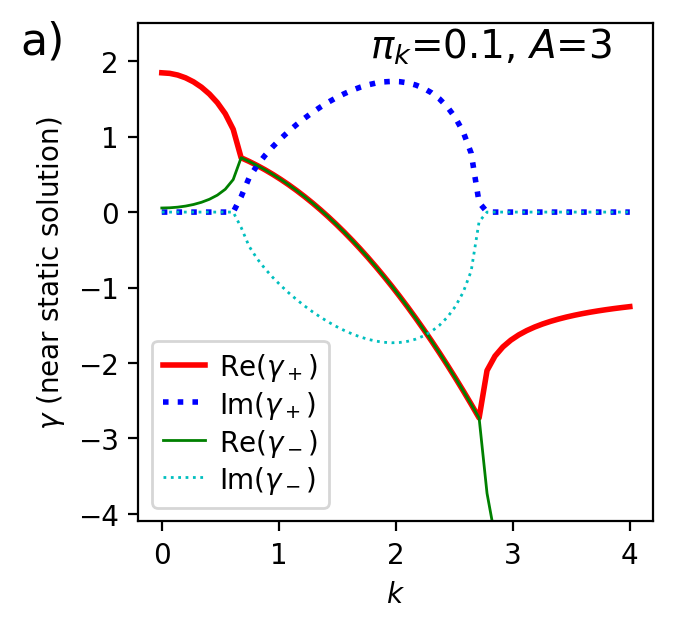

In [6]:

# make a figure showing the dispersion relation for solutions near the static one
def mk_fig1(klin,AA,pi_k,ofile):
    #klin = np.linspace(0,4,60) + 1e-4
    k2 = klin**2
    a = 1.0; b = pi_k + k2 - AA + 1.0; c = pi_k + k2  # parameters of quadratic dispersion relation 
    gam_plus  = 0.5*(-b + np.sqrt(b*b - 4*a*c + 0j))  # these are the roots
    gam_minus = 0.5*(-b - np.sqrt(b*b - 4*a*c + 0j))

    fig,ax = plt.subplots(1,1,figsize=(3.3,3),dpi=200)
    plt.subplots_adjust(left=0.2,right=0.98,top=0.98,bottom=0.15)

    ax.set_ylim(bottom=-4.1,top=2.5)

    #ax.plot(klin,0*klin,'k:', lw=0.5, label='')  # horizontal black dotted line
    ax.plot(klin,np.real(gam_plus),'r-',label=r'Re($\gamma_+$)',lw=2)
    ax.plot(klin,np.imag(gam_plus),'b:',label=r'Im($\gamma_+$)',lw=2)
    ax.plot(klin,np.real(gam_minus),'g-',label=r'Re($\gamma_-$)',lw=1)
    ax.plot(klin,np.imag(gam_minus),'c:',label=r'Im($\gamma_-$)',lw=1)

    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\gamma$ (near static solution)')

    if (pi_k < 0.1):
        parms_label = '$\pi_k$' + '={:.2f}'.format(pi_k) + ','
    else:
        parms_label = '$\pi_k$' + '={:.1f}'.format(pi_k) + ','
    parms_label += ' $A$' + '={:.0f}'.format(AA)


    ax.text(0.45,0.93,parms_label,transform=ax.transAxes,fontsize=14);
    ax.text(-0.23,0.94, 'a)', transform=ax.transAxes,fontsize=16);
    ax.legend(labelspacing=0.2,handlelength=1.5,handletextpad=0.5,handleheight=1)

    if (len(ofile)>3):
        fig.savefig(ofile)
    plt.show()

ofile = 'ReIm_gam_zz.png'
mk_fig1(klin,AA,pi_k,ofile)



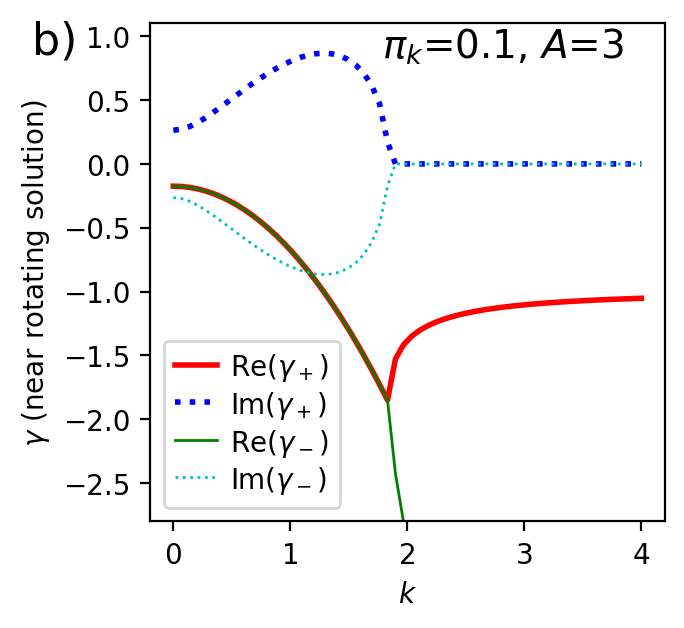

In [7]:
# make a figure showing the dispersion relation for solutions near the rotating state
#klin = np.linspace(0,4,50) + 1e-6
def mk_fig2(klin,AA,pi_k,p_star,ofile):

    # properties of the rotating solution 
    A_p0 = (AA - 1.0 - pi_k) * p_star /(1 + pi_k)  
    #A_u0 = (AA - 1.0 - pi_k) * p_star/np.sqrt(pi_k*(1 + pi_k))
    #ctheta0 = np.sqrt(pi_k/(1 + pi_k))
    #stheta0 = np.sqrt(1/(1 + pi_k))
    f0 = 1.0 + pi_k
    #f0A0 = f0*A_p0
    #dfA = (1 + pi_k)**2/AA

    g0 = f0 - f0**2*A_p0/(2*AA*p_star)
    #print('g0 = {:.3f}'.format(g0))

    k2 = klin**2
    a = 1.0; b = pi_k + k2 + 1.0 - g0; c = pi_k + k2 # parameters of quadratic dispersion relation 
    gam_plus = 0.5*(-b + np.sqrt(b*b - 4*a*c + 0j))  # roots 
    gam_minus = 0.5*(-b - np.sqrt(b*b - 4*a*c + 0j))

    fig,ax = plt.subplots(1,1,figsize=(3.3,3),dpi=200)
    plt.subplots_adjust(left=0.2,right=0.98,top=0.98,bottom=0.15)
    ax.set_ylim(bottom=-2.8,top=1.1)
    ax.plot(klin,np.real(gam_plus),'r-',label=r'Re($\gamma_+$)',lw=2)
    ax.plot(klin,np.imag(gam_plus),'b:',label=r'Im($\gamma_+$)',lw=2)
    ax.plot(klin,np.real(gam_minus),'g-',label=r'Re($\gamma_-$)',lw=1)
    ax.plot(klin,np.imag(gam_minus),'c:',label=r'Im($\gamma_-$)',lw=1)

    if (pi_k < 0.1):
        parms_label = '$\pi_k$' + '={:.2f}'.format(pi_k) + ','
    else:
        parms_label = '$\pi_k$' + '={:.1f}'.format(pi_k) + ','
    parms_label += ' $A$' + '={:.0f}'.format(AA)

    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\gamma$ (near rotating solution)')
    ax.text(0.45,0.93,parms_label,transform=ax.transAxes,fontsize=14);
    ax.text(-0.23,0.94, 'b)', transform=ax.transAxes,fontsize=16);
    ax.legend(handlelength=1.5,handletextpad=0.5,labelspacing=0.2,handleheight=1)

    if (len(ofile) >3):
        fig.savefig(ofile)
    plt.show()

ofile = 'ReIm_gam.png'
mk_fig2(klin,AA,pi_k,p_star,ofile)

# we have decaying wavelike solutions for $k <2$

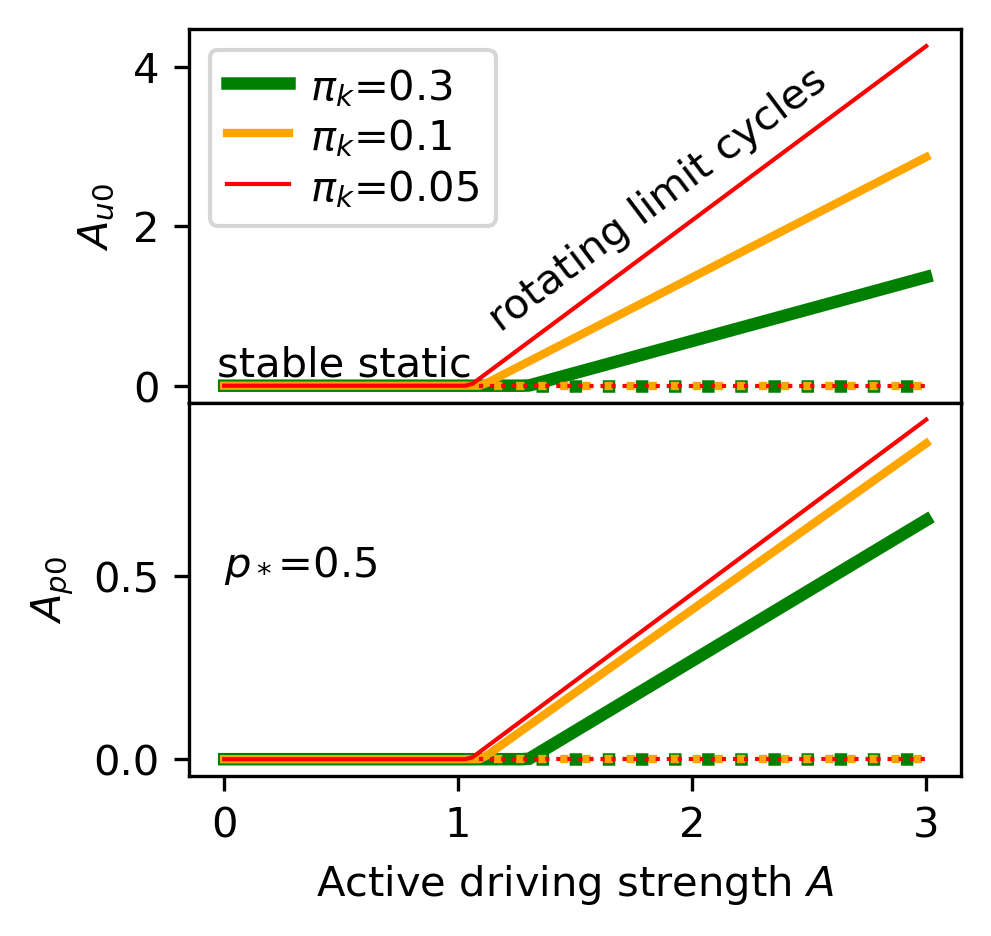

In [3]:
# make a bifurcation plot 
def mkfig3(pi_k_list,p_star):
    klin = np.linspace(0,4,60) + 1e-4
    k2 = klin*klin
    Alin = np.linspace(0,3,100)
    # dispersion relation for static solutions
    bifu = Alin*0.0 - 0.3
    bifp = Alin*0.0 - 0.1
    
    fig,axarr = plt.subplots(2,1,figsize=(3.3,3),dpi=300,sharex=True)
    plt.subplots_adjust(left=0.2,right=0.98,top=0.98,bottom=0.15,wspace=0,hspace=0)
    ax0 = axarr[0]
    ax1 = axarr[1]

    colorlist = ['red','orange','green','cyan','blue']
    lwlist = [1,2,3,4,5]

    for j in range(len(pi_k_list)-1,-1,-1):
        pi_k = pi_k_list[j]
        for k in range(len(Alin)):
            AA = Alin[k]
            a = 1.0; b = pi_k + k2 - AA + 1.0; c = pi_k + k2  # parameters of quadratic dispersion relation 
            gam_plus  = 0.5*(-b + np.sqrt(b*b - 4*a*c + 0j))  # these are the roots
            gam_minus = 0.5*(-b - np.sqrt(b*b - 4*a*c + 0j))
            max_Re_gam_plus = np.max(np.real(gam_plus))
            max_Re_gam_minus = np.max(np.real(gam_minus))
            max_gam = np.max((max_Re_gam_plus,max_Re_gam_minus))
            #print(max_Re_gam_plus, max_Re_gam_minus)
            A_u0 = (AA - 1.0 - pi_k) * p_star/np.sqrt(pi_k*(1 + pi_k))
            A_p0 = (AA - 1.0 - pi_k) * p_star /(1 + pi_k)  
            if (max_gam > 0):
                bifu[k] = A_u0
                bifp[k] = A_p0
            else:
                bifu[k] = 0.0
                bifp[k] = 0.0

        if (pi_k < 0.1):
            pi_k_label = r"$\pi_k$={:.2f}".format(pi_k)
        else:
            pi_k_label = r"$\pi_k$={:.1f}".format(pi_k)
        #ax.plot(Alin,bifu,'-',label=pi_k_label,color = colorlist[j],lw = lwlist[j])
        ax0.plot(Alin,bifu,'-',label=pi_k_label,color = colorlist[j],lw = lwlist[j])
        ax1.plot(Alin,bifp,'-',label=pi_k_label,color = colorlist[j],lw = lwlist[j])
        kk = (np.abs(bifp )> 0.01)
        ax0.plot(Alin[kk],bifu[kk]*0,':',color = colorlist[j],lw = lwlist[j])
        ax1.plot(Alin[kk],bifp[kk]*0,':',color = colorlist[j],lw = lwlist[j])
        
        
    ax0.set_ylabel(r'$A_{u0}$')
    ax1.set_ylabel(r'$A_{p0}$')
    ax0.legend(labelspacing=0.2,handlelength=1.5,handletextpad=0.5,handleheight=1)
    ax1.set_xlabel(r'Active driving strength $A$')
    plabel = r'$p_*$='
    plabel += '{:.1f}'.format(p_star)
    ax1.text(0,0.5,plabel)
    ax0.text(-0.03,0.13,'stable static')
    ax0.text(1.1,0.7,'rotating limit cycles',rotation=37)
    
    plt.savefig('bif.png')
    plt.show()


pi_k_list = [0.05,0.1,0.3]
mkfig3(pi_k_list,p_star)

### below for exploration 

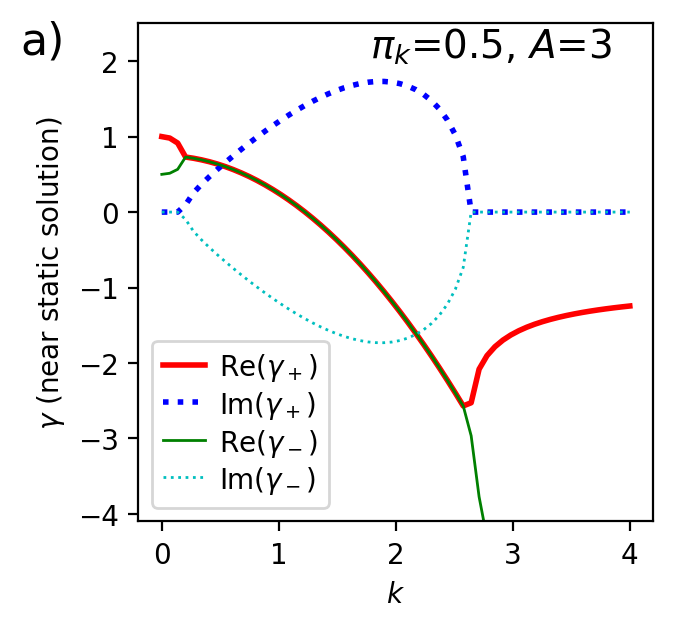

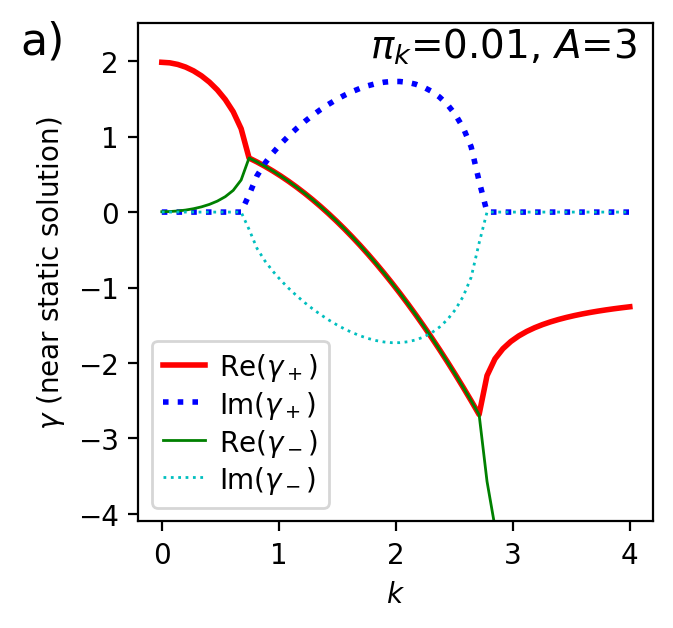

In [13]:
ofile = ''  # if you want to play around and see how the dispersion relations vary 
A_temp = 3; pi_temp = 0.5
mk_fig1(klin,A_temp,pi_temp,ofile)
pi_temp = 0.01
mk_fig1(klin,A_temp,pi_temp,ofile)
#mk_fig2(klin,A_temp,pi_temp,p_star,ofile)

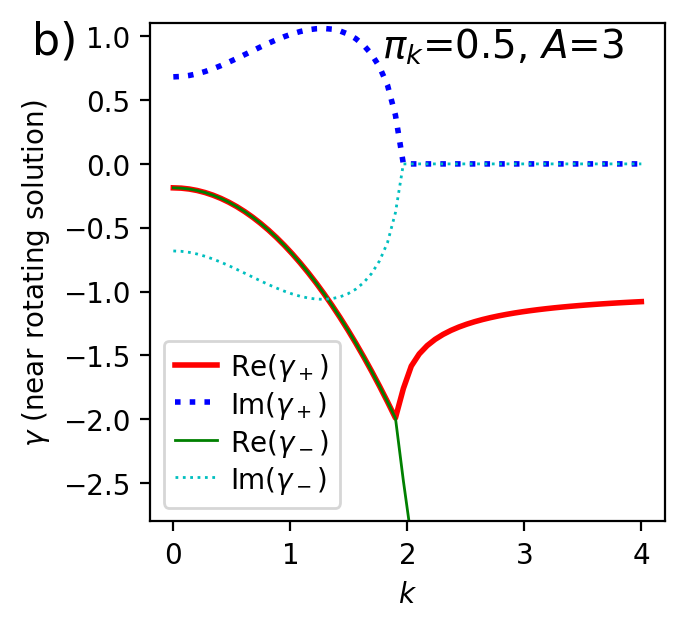

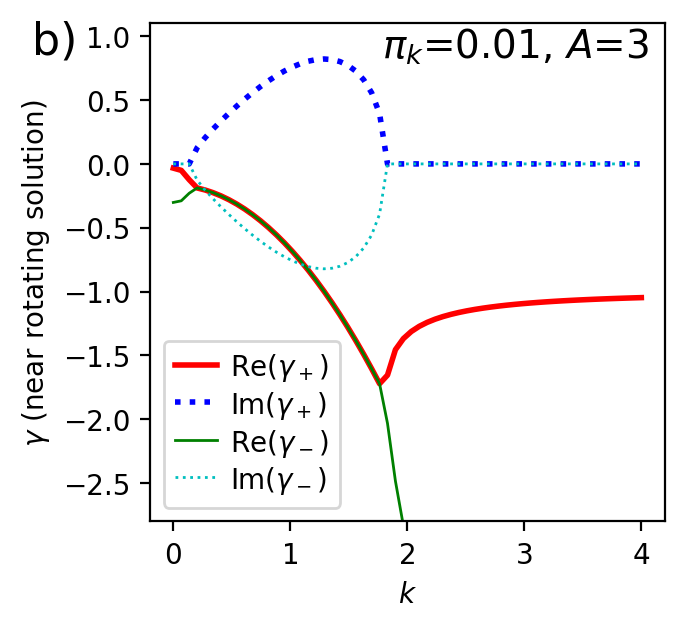

In [14]:
A_temp = 3; pi_temp = 0.5
mk_fig2(klin,A_temp,pi_temp,p_star,ofile)
pi_temp = 0.01
mk_fig2(klin,A_temp,pi_temp,p_star,ofile)
#mk_fig2(klin,A_temp,pi_temp,p_star,ofile)